# Why Activation Functions Matter — Building Intuition

We'll try to learn a simple curved function: **y = x²**

- Input 3 → Output 9
- Input -2 → Output 4
- Input 0 → Output 0

It's a U-shaped curve. A straight line can never be a U shape.
Let's see what happens when we try to learn it with and without activation functions.

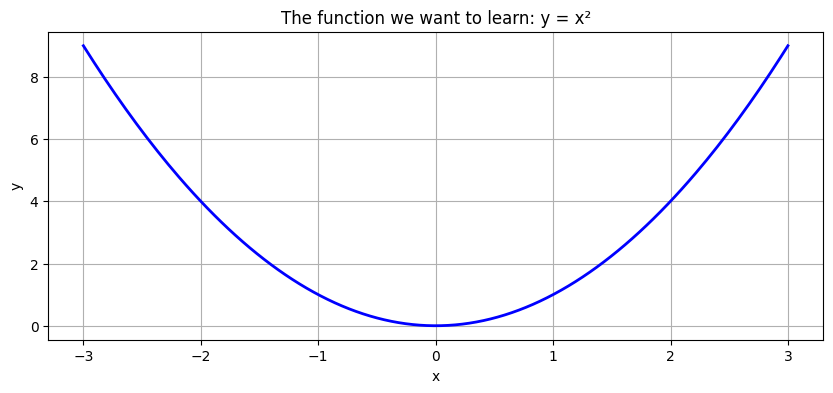

Simple U-shaped curve.
x=-3 → y=9,  x=-1 → y=1,  x=0 → y=0,  x=1 → y=1,  x=3 → y=9


In [1]:
# torch: PyTorch library — the main library for building and training neural networks
import torch
# torch.nn: the "neural network" module inside PyTorch — contains layers, loss functions, etc.
import torch.nn as nn
# matplotlib.pyplot: a plotting/charting library — we use it to draw graphs
import matplotlib.pyplot as plt

# Generate training data: y = x²

# torch.manual_seed(42): sets the random number generator to a fixed starting point
# so that every time you run this notebook, you get the exact same random numbers
# (weights are initialized randomly, so this makes results reproducible)
# 42 is just a convention — any number works
torch.manual_seed(42)

# torch.linspace(-3, 3, 200): creates 200 evenly spaced numbers from -3 to 3
#   result: tensor([-3.0, -2.97, -2.94, ..., 2.94, 2.97, 3.0])  — shape: (200,)
#
# .unsqueeze(1): adds an extra dimension at position 1, turning shape (200,) into (200, 1)
#   WHY? PyTorch neural networks expect input shaped as (num_samples, num_features)
#   We have 200 samples, each with 1 feature (just x), so we need shape (200, 1)
#   Without unsqueeze it's just a flat list, with unsqueeze it's a column — one row per sample
X = torch.linspace(-3, 3, 200).unsqueeze(1)  # 200 points from -3 to 3

# X ** 2: squares every element in X. If X has [-3, -2, 0, 2, 3], Y becomes [9, 4, 0, 4, 9]
# This is our target — what we want the network to learn to predict
Y = X ** 2                                     # target: x squared

# plt.figure(figsize=(10, 4)): creates a new blank chart/canvas
#   figsize=(10, 4) means 10 inches wide, 4 inches tall
plt.figure(figsize=(10, 4))

# plt.plot(x_values, y_values, style, linewidth): draws a line on the chart
#   X.numpy() converts the PyTorch tensor to a numpy array (matplotlib needs numpy, not torch)
#   'b-' means: 'b' = blue color, '-' = solid line (vs '--' for dashed)
#   linewidth=2 makes the line thicker (default is 1)
plt.plot(X.numpy(), Y.numpy(), 'b-', linewidth=2)

# plt.title(): adds a title text above the chart
plt.title('The function we want to learn: y = x²')
# plt.xlabel() / plt.ylabel(): labels for the x-axis and y-axis
plt.xlabel('x')
plt.ylabel('y')
# plt.grid(True): draws light gray grid lines on the chart for easier reading
plt.grid(True)
# plt.show(): actually renders and displays the chart on screen
plt.show()

print('Simple U-shaped curve.')
print('x=-3 → y=9,  x=-1 → y=1,  x=0 → y=0,  x=1 → y=1,  x=3 → y=9')

## Network WITHOUT activation (just linear layers)

Architecture: 1 input → 50 hidden → 50 hidden → 1 output

50 neurons per layer, 2 hidden layers. Surely enough? Let's see.

Final loss (no activation): 7.3449


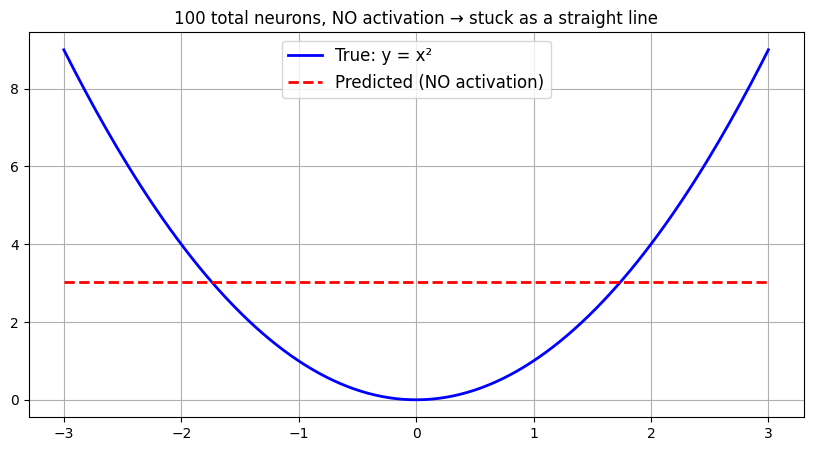

No matter how many neurons or layers — without activation, it can ONLY draw a straight line.
It tries its best to fit a line through the U-shape, but a line is all it has.


In [2]:
# nn.Sequential(): a container that chains layers together in order
#   When you pass input to it, it flows through layer 1, then layer 2, then layer 3, etc.
#   Think of it as a pipeline: input → layer1 → layer2 → layer3 → output
#
# nn.Linear(in_features, out_features): a single fully-connected (dense) layer
#   It computes: output = input @ W + b  (matrix multiply + bias)
#   nn.Linear(1, 50) means: takes 1 input, produces 50 outputs (50 neurons)
#   nn.Linear(50, 50) means: takes 50 inputs (from prev layer), produces 50 outputs
#   nn.Linear(50, 1) means: takes 50 inputs, produces 1 final output
linear_net = nn.Sequential(
    nn.Linear(1, 50),   # 50 neurons!
    # no activation
    nn.Linear(50, 50),  # 50 more neurons!
    # no activation
    nn.Linear(50, 1),
)

# torch.optim.Adam(): an optimizer — the algorithm that updates the weights to reduce the loss
#   Adam is a popular optimizer (smarter than basic gradient descent — adjusts learning rate per weight)
#   linear_net.parameters(): gives Adam all the weights and biases in the network to update
#   lr=0.01: learning rate — how big each weight update step is
#     too big = overshoots, too small = learns too slowly
optimizer = torch.optim.Adam(linear_net.parameters(), lr=0.01)

# nn.MSELoss(): Mean Squared Error loss function
#   Measures how far off predictions are from the true values
#   Formula: average of (prediction - true)² for all samples
#   If prediction=3 and true=5, error for that sample = (3-5)² = 4
#   Lower loss = better predictions
loss_fn = nn.MSELoss()

# Training loop: repeat 2000 times
for step in range(2000):
    # Forward pass: feed X through the network to get predictions
    pred = linear_net(X)
    # Compute loss: how far off are our predictions from the true Y?
    loss = loss_fn(pred, Y)
    # optimizer.zero_grad(): resets all gradient values to zero
    #   WHY? PyTorch accumulates (adds up) gradients by default
    #   Without zeroing, gradients from previous steps would pile up and be wrong
    optimizer.zero_grad()
    # loss.backward(): backpropagation — computes the gradient of the loss
    #   with respect to every weight in the network
    #   i.e., "how should each weight change to reduce the loss?"
    loss.backward()
    # optimizer.step(): actually updates the weights using the gradients computed above
    #   each weight moves a little bit in the direction that reduces the loss
    optimizer.step()

# loss.item(): extracts the loss value as a plain Python number (not a tensor)
print(f'Final loss (no activation): {loss.item():.4f}')

# torch.no_grad(): temporarily disables gradient tracking
#   WHY? We're just making predictions to plot, not training
#   Disabling gradients saves memory and computation
with torch.no_grad():
    pred_linear = linear_net(X)

plt.figure(figsize=(10, 5))
# Plotting two lines on the same chart:
#   label='...' gives each line a name that shows up in the legend
#   'r--' means: 'r' = red, '--' = dashed line
plt.plot(X.numpy(), Y.numpy(), 'b-', linewidth=2, label='True: y = x²')
plt.plot(X.numpy(), pred_linear.numpy(), 'r--', linewidth=2, label='Predicted (NO activation)')
plt.title('100 total neurons, NO activation → stuck as a straight line')
# plt.legend(): displays the box showing which color/style = which label
#   fontsize=12 makes the legend text size 12pt
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

print('No matter how many neurons or layers — without activation, it can ONLY draw a straight line.')
print('It tries its best to fit a line through the U-shape, but a line is all it has.')

## Network WITH activation (ReLU)

Same architecture: 1 input → 50 hidden → 50 hidden → 1 output

Only difference: ReLU activation between layers.

Final loss (with ReLU): 0.0000


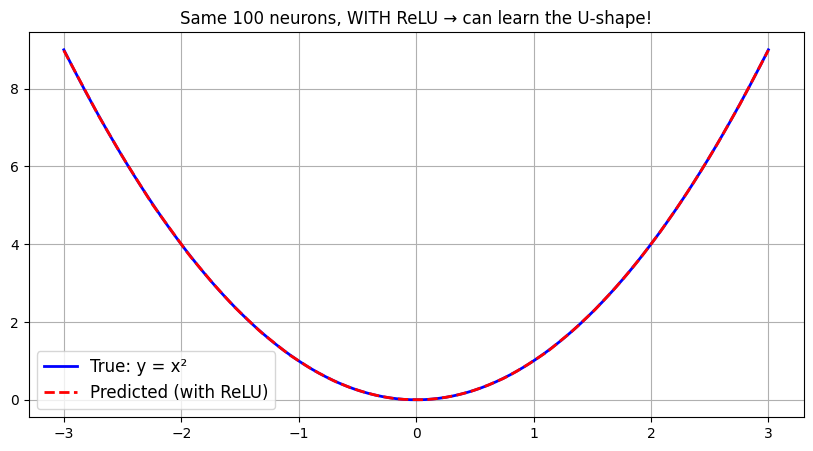

In [3]:
# nn.ReLU(): the Rectified Linear Unit activation function
#   Formula: ReLU(x) = max(0, x)
#   If input is positive, pass it through unchanged
#   If input is negative, output 0
#   Example: ReLU(3) = 3, ReLU(-5) = 0, ReLU(0) = 0
#   This is the nonlinear "squashing" function that prevents layers from collapsing
relu_net = nn.Sequential(
    nn.Linear(1, 50),
    nn.ReLU(),            # <-- the only difference
    nn.Linear(50, 50),
    nn.ReLU(),            # <-- and this
    nn.Linear(50, 1),
)

# Same optimizer setup as before, but for the new network's parameters
optimizer = torch.optim.Adam(relu_net.parameters(), lr=0.01)

# Same training loop — 2000 steps
for step in range(2000):
    pred = relu_net(X)
    loss = loss_fn(pred, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'Final loss (with ReLU): {loss.item():.4f}')

with torch.no_grad():
    pred_relu = relu_net(X)

plt.figure(figsize=(10, 5))
plt.plot(X.numpy(), Y.numpy(), 'b-', linewidth=2, label='True: y = x²')
plt.plot(X.numpy(), pred_relu.numpy(), 'r--', linewidth=2, label='Predicted (with ReLU)')
plt.title('Same 100 neurons, WITH ReLU → can learn the U-shape!')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## Side by side

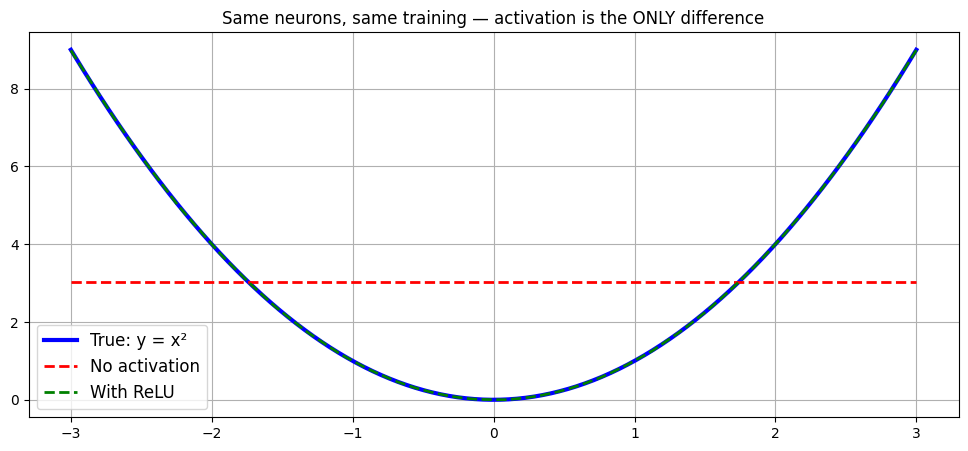

In [4]:
plt.figure(figsize=(12, 5))
# Plotting three lines on the same chart for comparison
#   'g--' means: 'g' = green, '--' = dashed line
plt.plot(X.numpy(), Y.numpy(), 'b-', linewidth=3, label='True: y = x²')
plt.plot(X.numpy(), pred_linear.numpy(), 'r--', linewidth=2, label='No activation')
plt.plot(X.numpy(), pred_relu.numpy(), 'g--', linewidth=2, label='With ReLU')
plt.title('Same neurons, same training — activation is the ONLY difference')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## THE KEY PART: What is each neuron actually doing?

Let's look inside the ReLU network at the first layer.

Each neuron computes: `ReLU(w*x + b) = max(0, w*x + b)`

That means:
- If `w*x + b` is positive → output that value (a rising or falling line)
- If `w*x + b` is negative → output 0 (flat, silent)

Each neuron is a line that's "on" in one region and "off" in another.

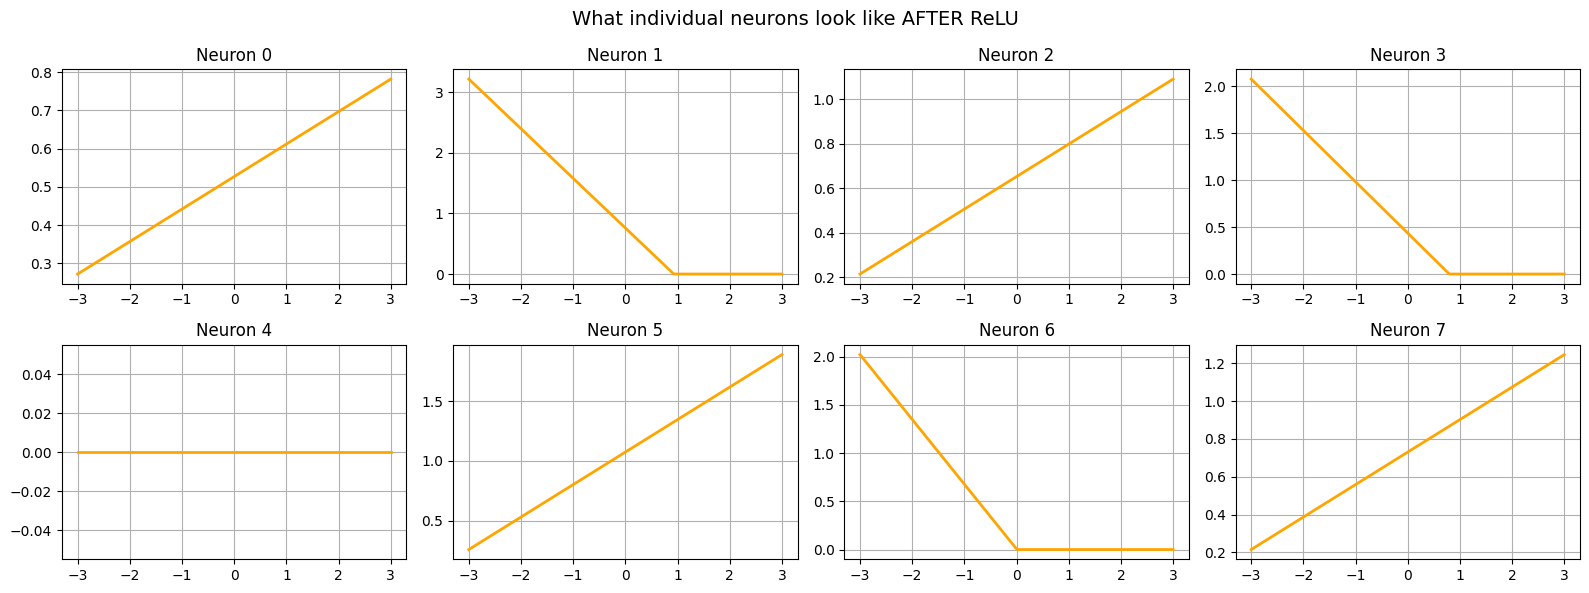

Each neuron: flat on one side, a line on the other.
The final output is a weighted SUM of all these.
Adding them together with the right weights → U-shape!


In [5]:
with torch.no_grad():
    # relu_net[0]: accesses the first layer in the Sequential container (index 0)
    #   relu_net is: [Linear, ReLU, Linear, ReLU, Linear]
    #   so relu_net[0] is the first nn.Linear(1, 50) layer
    #   Calling it with X gives us the raw output BEFORE ReLU is applied
    #   Shape: (200, 50) — 200 input samples, 50 neuron outputs each
    first_layer_output = relu_net[0](X)          # before ReLU
    # torch.relu(): applies the ReLU function element-wise to a tensor
    #   Same as nn.ReLU() but used as a standalone function instead of a layer
    #   Every negative value becomes 0, positive values stay the same
    after_relu = torch.relu(first_layer_output)   # after ReLU

# plt.subplots(rows, cols, figsize): creates a grid of multiple charts at once
#   (2, 4) means 2 rows, 4 columns = 8 small charts in a grid
#   Returns: fig (the overall figure) and axes (a 2D array of individual chart areas)
#   axes[0][0] is top-left chart, axes[1][3] is bottom-right chart
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

# fig.suptitle(): adds a "super title" — a title for the entire figure (above all subplots)
fig.suptitle('What individual neurons look like AFTER ReLU', fontsize=14)

for i in range(8):
    # i // 4: integer division — gives the row index (0 for i=0..3, 1 for i=4..7)
    # i % 4: remainder — gives the column index (0,1,2,3,0,1,2,3)
    ax = axes[i // 4][i % 4]
    # after_relu[:, i]: slices the tensor — all 200 samples (:), but only neuron i's output
    #   ':' means "all rows" (all 200 x values)
    #   'i' means "column i" (the i-th neuron's output)
    ax.plot(X.numpy(), after_relu[:, i].numpy(), 'orange', linewidth=2)
    # ax.set_title(): title for this individual subplot
    ax.set_title(f'Neuron {i}')
    ax.grid(True)

# plt.tight_layout(): automatically adjusts spacing between subplots so they don't overlap
plt.tight_layout()
plt.show()

print('Each neuron: flat on one side, a line on the other.')
print('The final output is a weighted SUM of all these.')
print('Adding them together with the right weights → U-shape!')

## Building the curve piece by piece

Watch what happens as we increase the number of neurons from 1 to 50.

Each neuron adds one more "bend" to the function.

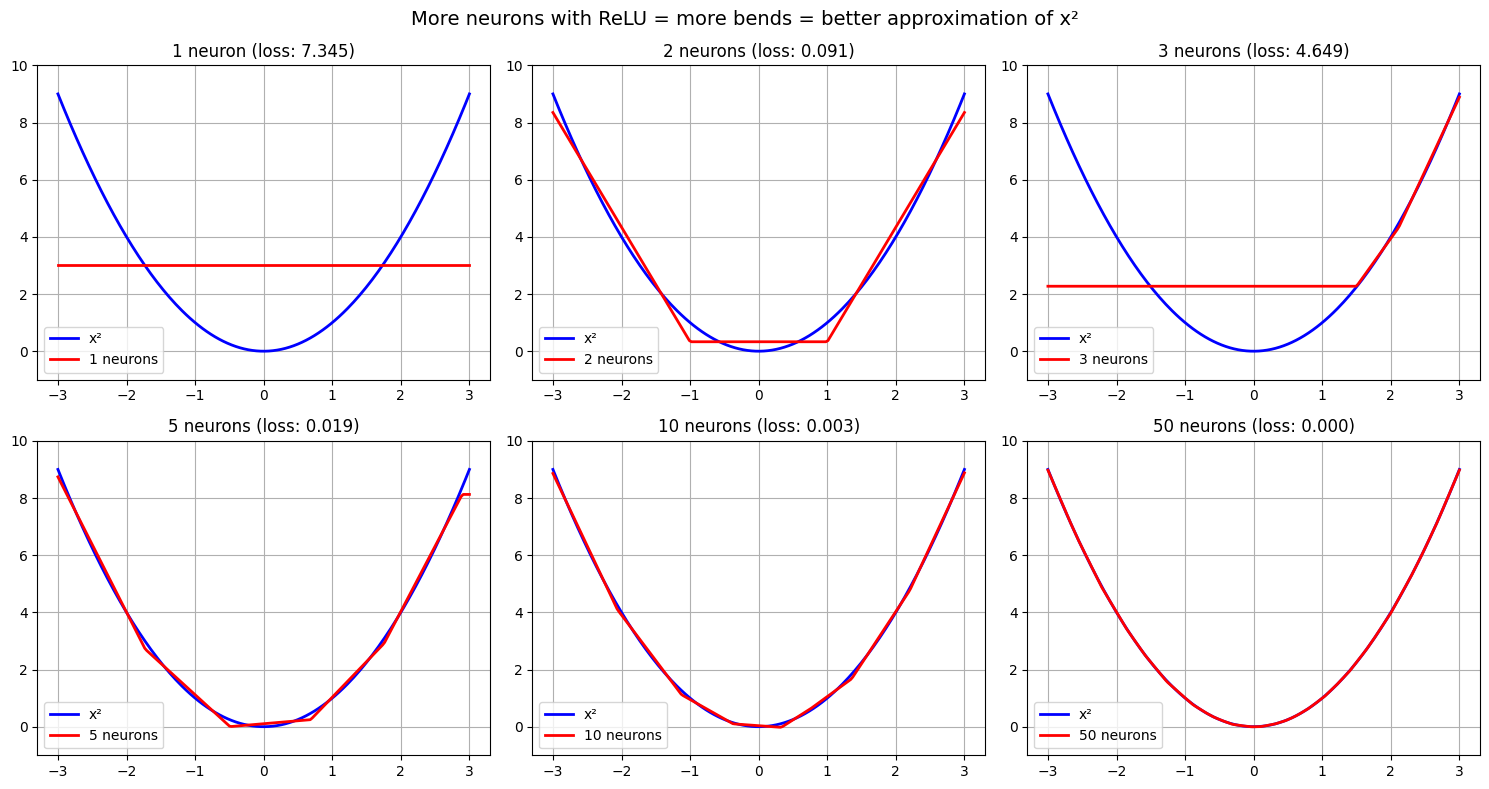

1 neuron  → 1 bend. Just a kink. Cannot make a U.
2 neurons → 2 bends. Can make a V shape! Close to U but pointy.
3 neurons → 3 bends. Smoother.
5 neurons → Pretty good U shape.
10 neurons → Almost perfect.
50 neurons → Nailed it.

The network builds the curve out of straight line segments.
More neurons = more segments = smoother curve.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# We'll train 6 separate networks, each with a different number of neurons
neuron_counts = [1, 2, 3, 5, 10, 50]

# enumerate(): loops through the list and gives you both the index (i) and the value (n)
#   i=0,n=1 then i=1,n=2 then i=2,n=3 etc.
for i, n in enumerate(neuron_counts):
    # Pick the right subplot from the grid
    # i=0 → row 0, col 0 | i=1 → row 0, col 1 | i=2 → row 0, col 2
    # i=3 → row 1, col 0 | i=4 → row 1, col 1 | i=5 → row 1, col 2
    ax = axes[i // 3][i % 3]
    
    # Build a fresh small network with n neurons in the hidden layer
    net = nn.Sequential(
        nn.Linear(1, n),
        nn.ReLU(),
        nn.Linear(n, 1),
    )
    opt = torch.optim.Adam(net.parameters(), lr=0.01)
    
    # Train this network for 3000 steps
    for step in range(3000):
        pred = net(X)
        loss = loss_fn(pred, Y)
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    with torch.no_grad():
        pred = net(X)
    
    ax.plot(X.numpy(), Y.numpy(), 'b-', linewidth=2, label='x²')
    ax.plot(X.numpy(), pred.numpy(), 'r-', linewidth=2, label=f'{n} neurons')
    ax.set_title(f'{n} neuron{"s" if n > 1 else ""} (loss: {loss.item():.3f})')
    # ax.legend(): shows the legend box on this specific subplot
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-1, 10): sets the y-axis range from -1 to 10
    #   so all subplots have the same scale and are easy to compare
    ax.set_ylim(-1, 10)

plt.suptitle('More neurons with ReLU = more bends = better approximation of x²', fontsize=14)
plt.tight_layout()
plt.show()

print('1 neuron  → 1 bend. Just a kink. Cannot make a U.')
print('2 neurons → 2 bends. Can make a V shape! Close to U but pointy.')
print('3 neurons → 3 bends. Smoother.')
print('5 neurons → Pretty good U shape.')
print('10 neurons → Almost perfect.')
print('50 neurons → Nailed it.')
print()
print('The network builds the curve out of straight line segments.')
print('More neurons = more segments = smoother curve.')

In [7]:
# 5 nurons mlp weights and bias
net = nn.Sequential(
    nn.Linear(1, 5),
    nn.ReLU(),
    nn.Linear(5, 1),
)
opt = torch.optim.Adam(net.parameters(), lr=0.01)

# Train this network for 3000 steps
for step in range(3000):
    pred = net(X)
    loss = loss_fn(pred, Y)
    opt.zero_grad()
    loss.backward()
    opt.step()

with torch.no_grad():
    pred = net(X)

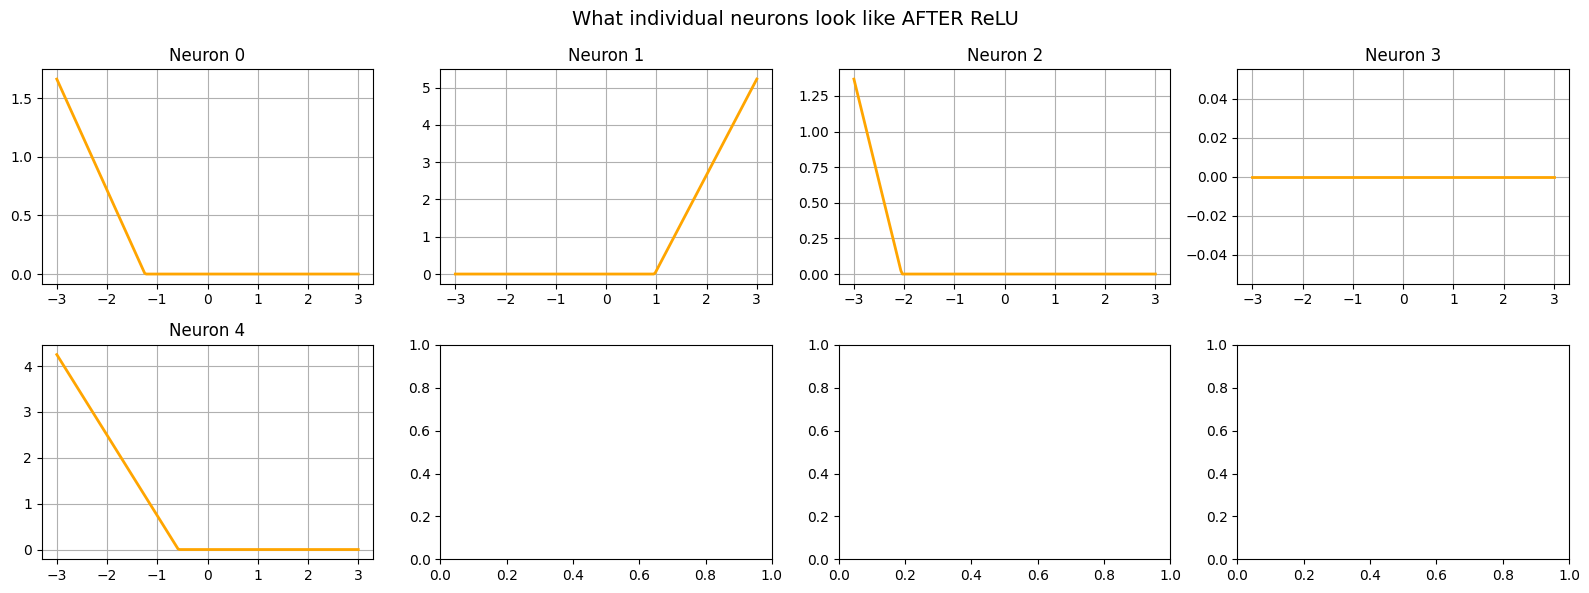

Each neuron: flat on one side, a line on the other.
The final output is a weighted SUM of all these.
Adding them together with the right weights → U-shape!


In [9]:
with torch.no_grad():
    # relu_net[0]: accesses the first layer in the Sequential container (index 0)
    #   relu_net is: [Linear, ReLU, Linear, ReLU, Linear]
    #   so relu_net[0] is the first nn.Linear(1, 50) layer
    #   Calling it with X gives us the raw output BEFORE ReLU is applied
    #   Shape: (200, 50) — 200 input samples, 50 neuron outputs each
    first_layer_output = net[0](X)          # before ReLU
    # torch.relu(): applies the ReLU function element-wise to a tensor
    #   Same as nn.ReLU() but used as a standalone function instead of a layer
    #   Every negative value becomes 0, positive values stay the same
    after_relu = torch.relu(first_layer_output)   # after ReLU

# plt.subplots(rows, cols, figsize): creates a grid of multiple charts at once
#   (2, 4) means 2 rows, 4 columns = 8 small charts in a grid
#   Returns: fig (the overall figure) and axes (a 2D array of individual chart areas)
#   axes[0][0] is top-left chart, axes[1][3] is bottom-right chart
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

# fig.suptitle(): adds a "super title" — a title for the entire figure (above all subplots)
fig.suptitle('What individual neurons look like AFTER ReLU', fontsize=14)

for i in range(5):
    # i // 4: integer division — gives the row index (0 for i=0..3, 1 for i=4..7)
    # i % 4: remainder — gives the column index (0,1,2,3,0,1,2,3)
    ax = axes[i // 4][i % 4]
    # after_relu[:, i]: slices the tensor — all 200 samples (:), but only neuron i's output
    #   ':' means "all rows" (all 200 x values)
    #   'i' means "column i" (the i-th neuron's output)
    ax.plot(X.numpy(), after_relu[:, i].numpy(), 'orange', linewidth=2)
    # ax.set_title(): title for this individual subplot
    ax.set_title(f'Neuron {i}')
    ax.grid(True)

# plt.tight_layout(): automatically adjusts spacing between subplots so they don't overlap
plt.tight_layout()
plt.show()

print('Each neuron: flat on one side, a line on the other.')
print('The final output is a weighted SUM of all these.')
print('Adding them together with the right weights → U-shape!')

In [11]:
net(torch.tensor([[2.0]]))

tensor([[4.3501]], grad_fn=<AddmmBackward0>)